In [1]:
# imports
# imports
from src.helpers.gromacs import *
import os
import numpy as np
import matplotlib.pyplot as plt
import warnings
import nglview as nv


Helper functions loaded.


In [171]:
# Mapping of accessions
mapping={'psychrophiles': ['YCB25778', 'UFK27161', 'YCQ78089'],
 'thermophiles': ['YP_874025', 'YP_004782219', 'AHZ95250'],
 'mesophiles': ['XCZ64124', 'WAX22921', 'UUV43823'],
 'hottest': ['YP_009791320', 'YP_004322308', 'XYR95885'],
 'coldest': ['XQO94789', 'YP_009151072', 'YP_007010273'],
 'random': ['YP_009213881', 'UVK61175', 'CAD5240622']}

accs=[item for sublist in mapping.values() for item in sublist]

In [172]:
# set protein
acc='UFK27161'

In [173]:
# Visualise original structure
pdb=f'../../../../uvsx/data/gmx_prep/structures/{acc.lower()}/{acc.lower()}.pdb'
view = nv.show_structure_file(pdb)
view


NGLWidget()

# Visualise Trajectory

In [201]:
import MDAnalysis as mda
import nglview as nv



u1 = mda.Universe(f"{acc}/psychrophilic/results/boxed.gro", f"{acc}/psychrophilic/results/md_center.xtc")
u2 = mda.Universe(f"{acc}/mesophilic/results/boxed.gro", f"{acc}/mesophilic/results/md_center.xtc")
u3 = mda.Universe(f"{acc}/thermophilic/results/boxed.gro", f"{acc}/thermophilic/results/md_center.xtc")

view = nv.NGLWidget()

c0=view.add_trajectory(u1) # psychrophilic
c1=view.add_trajectory(u2) # mesophilic
c2=view.add_trajectory(u3) # thermophilic

# Clear and style each component separately
# IMPORTANT: clear per component, not globally ambiguous
view.clear_representations(component=0)
view.clear_representations(component=1)
view.clear_representations(component=2)


view.add_cartoon("protein", component=0, color="blue")
view.add_cartoon("protein", component=1, color="green")
view.add_cartoon("protein", component=2, color="red")

#offset each protein so they dont overlap
c0.set_position([75, 100, 0])
c1.set_position([0, 100, 0])
c2.set_position([-75, 100, 0])


view.center()
view

NGLWidget(max_frame=2000)

# Energy Minisation


Psychrophilic
Initial Epot: -996,416 kJ/mol
Final   Epot: -1,874,609 kJ/mol
Change:       -878,193 kJ/mol

Mesophilic
Initial Epot: -990,160 kJ/mol
Final   Epot: -1,872,967 kJ/mol
Change:       -882,807 kJ/mol

Thermophilic
Initial Epot: -990,039 kJ/mol
Final   Epot: -1,873,934 kJ/mol
Change:       -883,895 kJ/mol


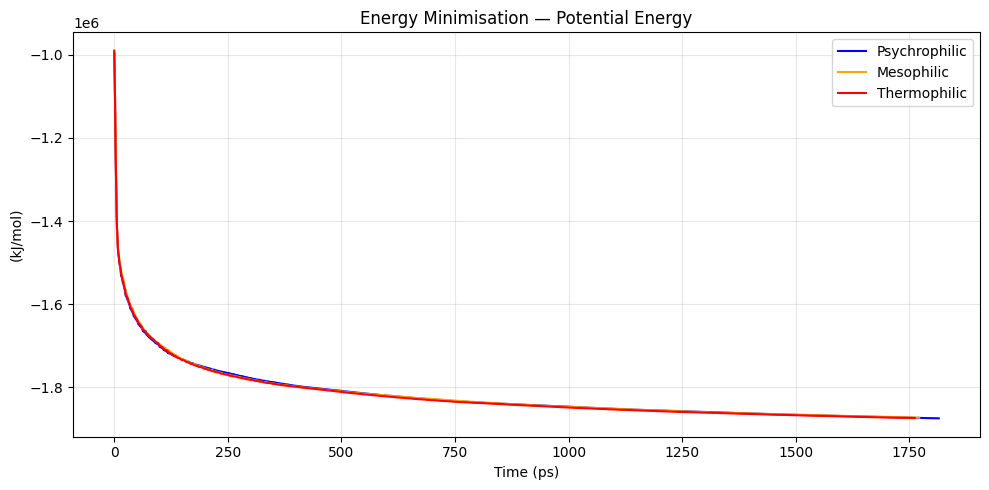

In [187]:
import matplotlib.pyplot as plt

files = {
    "Psychrophilic": f"{acc}/psychrophilic/results/potential.xvg",
    "Mesophilic": f"{acc}/mesophilic/results/potential.xvg",
    "Thermophilic": f"{acc}/thermophilic/results/potential.xvg",
}

colors = {
    "Psychrophilic": "blue",
    "Mesophilic": "orange",
    "Thermophilic": "red",
}

plt.figure(figsize=(10, 5))

for label, file in files.items():
    d = parse_xvg(file)

    x = d["time"]
    epot = d["columns"][:, 0]

    plt.plot(x, epot, label=label, color=colors[label])

    print(f"\n{label}")
    print(f"Initial Epot: {epot[0]:,.0f} kJ/mol")
    print(f"Final   Epot: {epot[-1]:,.0f} kJ/mol")
    print(f"Change:       {epot[-1] - epot[0]:,.0f} kJ/mol")

plt.title("Energy Minimisation — Potential Energy")
plt.xlabel(d["xlabel"])
plt.ylabel(d["ylabel"])

plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# NVT Equilibration - Temperature


Psychrophilic
Mean temperature: 288.0 K
Std deviation:    0.7 K

Mesophilic
Mean temperature: 310.1 K
Std deviation:    0.9 K

Thermophilic
Mean temperature: 338.6 K
Std deviation:    1.0 K


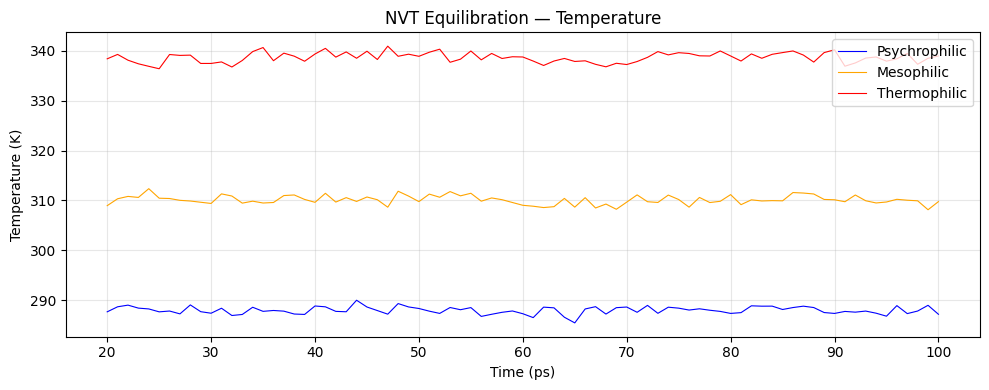

In [188]:
import matplotlib.pyplot as plt
import numpy as np

files = {
    "Psychrophilic": f"{acc}/psychrophilic/results/temperature.xvg",
    "Mesophilic": f"{acc}/mesophilic/results/temperature.xvg",
    "Thermophilic": f"{acc}/thermophilic/results/temperature.xvg",
}

colors = {
    "Psychrophilic": "blue",
    "Mesophilic": "orange",
    "Thermophilic": "red",
}

fig, ax = plt.subplots(figsize=(10, 4))

for label, file in files.items():
    d = parse_xvg(file)

    x = d["time"]
    temp = d["columns"][:, 0]

    ax.plot(x, temp, linewidth=0.8, label=label, color=colors[label])

    print(f"\n{label}")
    print(f"Mean temperature: {np.mean(temp):.1f} K")
    print(f"Std deviation:    {np.std(temp):.1f} K")


ax.set_title("NVT Equilibration — Temperature")
ax.set_xlabel(d["xlabel"])
ax.set_ylabel("Temperature (K)")

ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# NPT Equilibration - Pressure


Psychrophilic
Mean pressure:  -37.4 bar
Std deviation:  102.0 bar
RMSE from 1 bar:108.9 bar

Mesophilic
Mean pressure:  14.4 bar
Std deviation:  85.4 bar
RMSE from 1 bar:86.4 bar

Thermophilic
Mean pressure:  29.1 bar
Std deviation:  117.8 bar
RMSE from 1 bar:121.1 bar


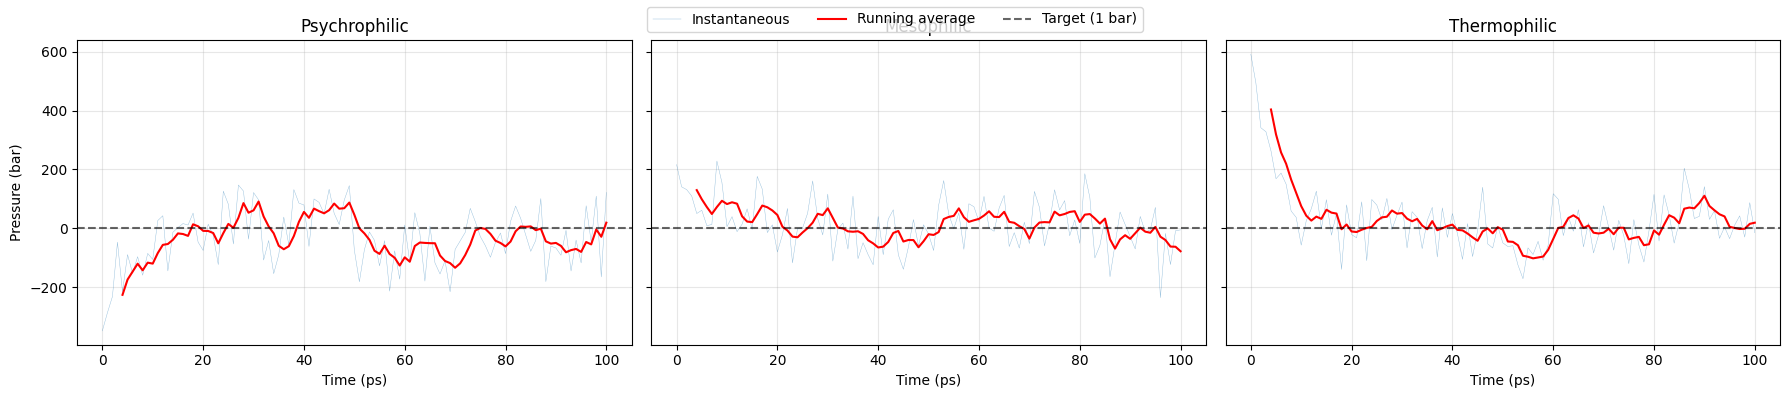

In [189]:
import matplotlib.pyplot as plt
import numpy as np

files = {
    "Psychrophilic": f"{acc}/psychrophilic/results/pressure.xvg",
    "Mesophilic": f"{acc}/mesophilic/results/pressure.xvg",
    "Thermophilic": f"{acc}/thermophilic/results/pressure.xvg",
}

fig, axes = plt.subplots(1, 3, figsize=(18, 4), sharey=True)

for ax, (label, file) in zip(axes, files.items()):
    d = parse_xvg(file)

    x = d["time"]
    pressure = d["columns"][:, 0]

    ax.plot(x, pressure, linewidth=0.3, alpha=0.5, label="Instantaneous")

    window = max(1, len(pressure) // 20)
    running_avg = np.convolve(pressure, np.ones(window)/window, mode="valid")

    ax.plot(
        x[window-1:],
        running_avg,
        linewidth=1.5,
        color="red",
        label="Running average"
    )

    ax.axhline(
        y=1,
        color="black",
        linestyle="--",
        alpha=0.6,
        label="Target (1 bar)"
    )

    ax.set_title(label)
    ax.set_xlabel(d["xlabel"])
    ax.grid(True, alpha=0.3)

    print(f"\n{label}")
    print(f"Mean pressure:  {np.mean(pressure):.1f} bar")
    print(f"Std deviation:  {np.std(pressure):.1f} bar")
    print(f"RMSE from 1 bar:{np.sqrt(np.mean((pressure - 1)**2)):.1f} bar")

axes[0].set_ylabel("Pressure (bar)")

# single shared legend (cleaner than repeating 3 times)
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper center", ncol=3)

plt.tight_layout()
plt.show()

# NPT Equilibration - Density


Psychrophilic
Mean density:  1007.7 kg/m³
Std deviation: 3.1 kg/m³

Mesophilic
Mean density:  991.1 kg/m³
Std deviation: 1.6 kg/m³

Thermophilic
Mean density:  965.3 kg/m³
Std deviation: 5.6 kg/m³


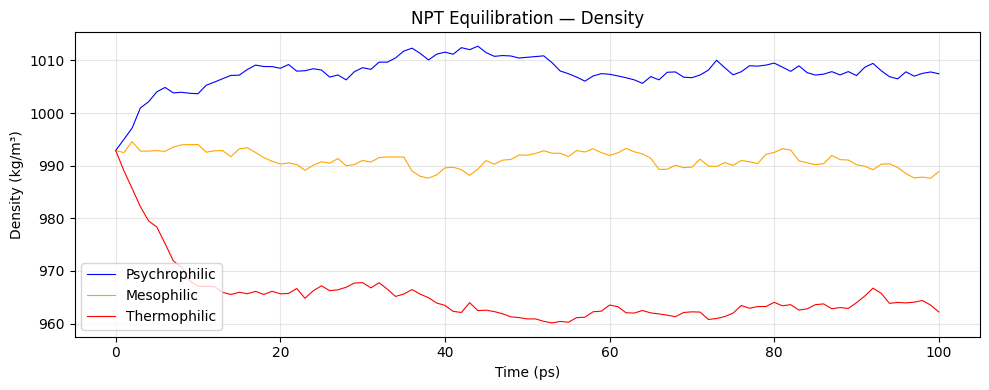

In [190]:
import matplotlib.pyplot as plt
import numpy as np

files = {
    "Psychrophilic": f"{acc}/psychrophilic/results/density.xvg",
    "Mesophilic": f"{acc}/mesophilic/results/density.xvg",
    "Thermophilic": f"{acc}/thermophilic/results/density.xvg",
}

colors = {
    "Psychrophilic": "blue",
    "Mesophilic": "orange",
    "Thermophilic": "red",
}

fig, ax = plt.subplots(figsize=(10, 4))

for label, file in files.items():
    d = parse_xvg(file)

    x = d["time"]
    density = d["columns"][:, 0]

    ax.plot(x, density, linewidth=0.8, label=label, color=colors[label])

    print(f"\n{label}")
    print(f"Mean density:  {np.mean(density):.1f} kg/m³")
    print(f"Std deviation: {np.std(density):.1f} kg/m³")

ax.set_title("NPT Equilibration — Density")
ax.set_xlabel(d["xlabel"])
ax.set_ylabel("Density (kg/m³)")

ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Minimum Image distance


Psychrophilic
Minimum distance observed: 1.289 nm
Mean distance:             2.926 nm

✓ OK: Minimum distance always exceeds 1.2 nm cutoff.

Mesophilic
Minimum distance observed: 2.060 nm
Mean distance:             3.326 nm

✓ OK: Minimum distance always exceeds 1.2 nm cutoff.

Thermophilic
Minimum distance observed: 1.609 nm
Mean distance:             3.559 nm

✓ OK: Minimum distance always exceeds 1.2 nm cutoff.


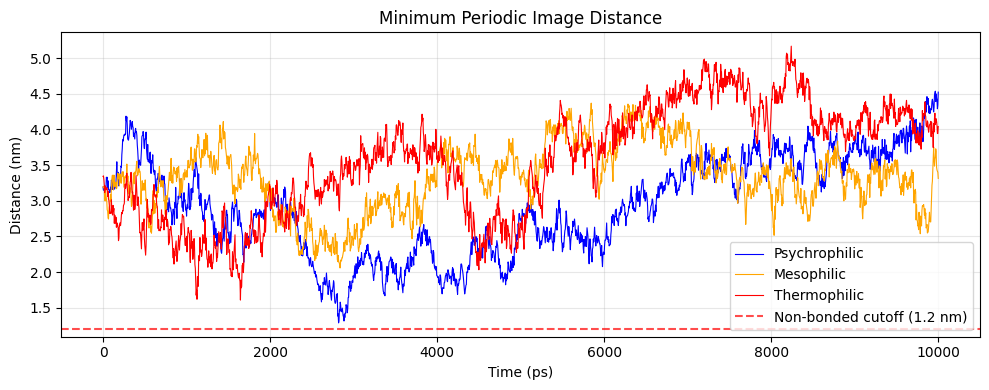

In [191]:
import matplotlib.pyplot as plt
import numpy as np

files = {
    "Psychrophilic": f"{acc}/psychrophilic/results/mindist.xvg",
    "Mesophilic": f"{acc}/mesophilic/results/mindist.xvg",
    "Thermophilic": f"{acc}/thermophilic/results/mindist.xvg",
}

colors = {
    "Psychrophilic": "blue",
    "Mesophilic": "orange",
    "Thermophilic": "red",
}

fig, ax = plt.subplots(figsize=(10, 4))

for label, file in files.items():
    d = parse_xvg(file)

    x = d["time"]
    mindist = d["columns"][:, 0]

    ax.plot(x, mindist, linewidth=0.8, label=label, color=colors[label])

    print(f"\n{label}")
    print(f"Minimum distance observed: {np.min(mindist):.3f} nm")
    print(f"Mean distance:             {np.mean(mindist):.3f} nm")

    if np.min(mindist) < 1.2:
        print("\n⚠️  WARNING: Distance dropped below 1.2 nm cutoff — periodic images may interact!")
        print("   Consider using a larger box (increase -d value in gmx editconf).")
    else:
        print("\n✓ OK: Minimum distance always exceeds 1.2 nm cutoff.")

# cutoff line
ax.axhline(
    y=1.2,
    color="red",
    linestyle="--",
    alpha=0.7,
    label="Non-bonded cutoff (1.2 nm)"
)

ax.set_title("Minimum Periodic Image Distance")
ax.set_xlabel(d["xlabel"])
ax.set_ylabel("Distance (nm)")

ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# RMSD - Structural Stability


Psychrophilic
Final RMSD:         1.265 nm (12.7 Å)
Mean RMSD:          0.864 nm (8.6 Å)
Mean (last 25%):    1.210 nm (12.1 Å)

Mesophilic
Final RMSD:         1.076 nm (10.8 Å)
Mean RMSD:          0.955 nm (9.6 Å)
Mean (last 25%):    1.112 nm (11.1 Å)

Thermophilic
Final RMSD:         1.359 nm (13.6 Å)
Mean RMSD:          1.218 nm (12.2 Å)
Mean (last 25%):    1.423 nm (14.2 Å)


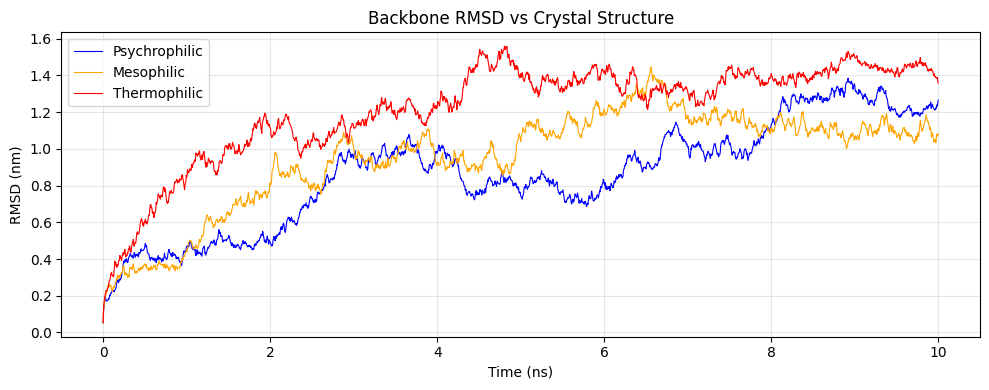

In [192]:
import matplotlib.pyplot as plt
import numpy as np

files = {
    "Psychrophilic": f"{acc}/psychrophilic/results/rmsd.xvg",
    "Mesophilic": f"{acc}/mesophilic/results/rmsd.xvg",
    "Thermophilic": f"{acc}/thermophilic/results/rmsd.xvg",
}

colors = {
    "Psychrophilic": "blue",
    "Mesophilic": "orange",
    "Thermophilic": "red",
}

fig, ax = plt.subplots(figsize=(10, 4))

for label, file in files.items():
    d = parse_xvg(file)

    x = d["time"]
    rmsd = d["columns"][:, 0]

    ax.plot(x, rmsd, linewidth=0.8, label=label, color=colors[label])

    print(f"\n{label}")
    print(f"Final RMSD:         {rmsd[-1]:.3f} nm ({rmsd[-1]*10:.1f} Å)")
    print(f"Mean RMSD:          {np.mean(rmsd):.3f} nm ({np.mean(rmsd)*10:.1f} Å)")
    print(f"Mean (last 25%):    {np.mean(rmsd[len(rmsd)*3//4:]):.3f} nm "
          f"({np.mean(rmsd[len(rmsd)*3//4:])*10:.1f} Å)")

ax.set_title("Backbone RMSD vs Crystal Structure")
ax.set_xlabel(d["xlabel"])
ax.set_ylabel("RMSD (nm)")

ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(f'plots/{acc}_RMSD.png', dpi=300, bbox_inches='tight')
plt.show()

# Radius of Gyration


Psychrophilic
Mean Rg:            2.676 nm
Std deviation:      0.112 nm
Mean Rg (last 25%): 2.503 nm

Mesophilic
Mean Rg:            2.644 nm
Std deviation:      0.092 nm
Mean Rg (last 25%): 2.622 nm

Thermophilic
Mean Rg:            2.555 nm
Std deviation:      0.151 nm
Mean Rg (last 25%): 2.406 nm


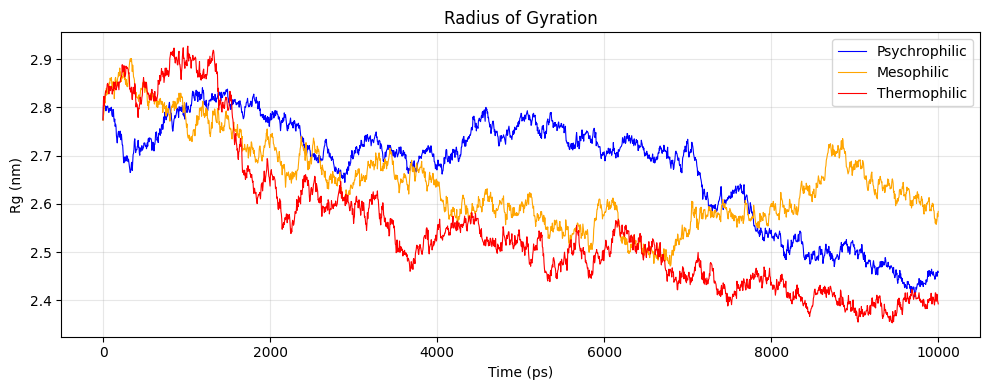

In [193]:
import matplotlib.pyplot as plt
import numpy as np

files = {
    "Psychrophilic": f"{acc}/psychrophilic/results/gyrate.xvg",
    "Mesophilic": f"{acc}/mesophilic/results/gyrate.xvg",
    "Thermophilic": f"{acc}/thermophilic/results/gyrate.xvg",
}

colors = {
    "Psychrophilic": "blue",
    "Mesophilic": "orange",
    "Thermophilic": "red",
}


fig, ax = plt.subplots(figsize=(10, 4))

for label, file in files.items():
    d = parse_xvg(file)

    x = d["time"]
    rg = d["columns"][:, 0]

    ax.plot(x, rg, linewidth=0.8, label=label, color=colors[label])

    print(f"\n{label}")
    print(f"Mean Rg:            {np.mean(rg):.3f} nm")
    print(f"Std deviation:      {np.std(rg):.3f} nm")
    print(f"Mean Rg (last 25%): {np.mean(rg[len(rg)*3//4:]):.3f} nm")

ax.set_title("Radius of Gyration")
ax.set_xlabel(d["xlabel"])
ax.set_ylabel("Rg (nm)")

ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Residue Fluctuation


Psychrophilic
Mean Rmsf:            0.879 nm
Std deviation:      0.642 nm
Mean Rmsf (last 25%): 1.505 nm

Mesophilic
Mean Rmsf:            0.513 nm
Std deviation:      0.309 nm
Mean Rmsf (last 25%): 0.867 nm

Thermophilic
Mean Rmsf:            0.561 nm
Std deviation:      0.358 nm
Mean Rmsf (last 25%): 0.934 nm


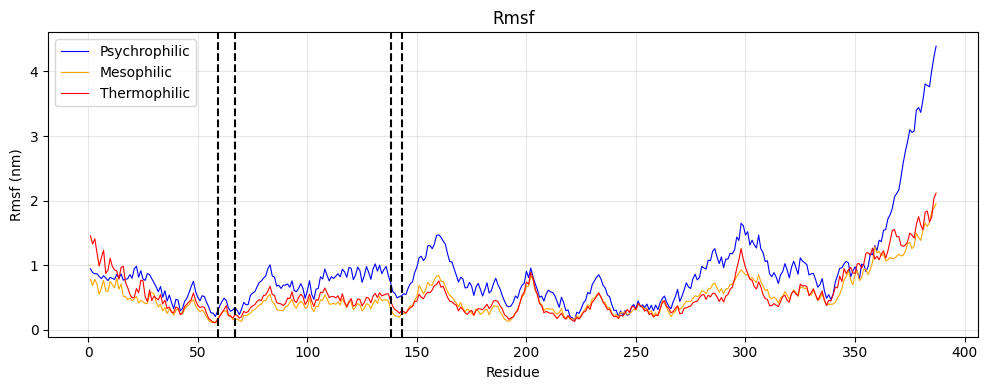

In [197]:
import matplotlib.pyplot as plt
import numpy as np
from src.biotools.fasta_tools import *

files = {
    "Psychrophilic": f"{acc}/psychrophilic/results/rmsf.xvg",
    "Mesophilic": f"{acc}/mesophilic/results/rmsf.xvg",
    "Thermophilic": f"{acc}/thermophilic/results/rmsf.xvg",
}

colors = {
    "Psychrophilic": "blue",
    "Mesophilic": "orange",
    "Thermophilic": "red",
}

# Get motifs
seq=ExtractSequence(acc, '../../../../uvsx/data/curated_database/top_hits.fasta')
walker_a=r"[GA]....[GF]K[TS]"
matches_a = [(m.start(),m.end(), m.group()) for m in re.finditer(walker_a, seq)]
a_start=matches_a[0][0]
a_end=matches_a[0][1]

walker_b=r"[AVILMFWY]{4}DE?"
matches_b = [(m.start(),m.end(), m.group()) for m in re.finditer(walker_b, seq)]
b_start=matches_b[0][0]
b_end=matches_b[0][1]


fig, ax = plt.subplots(figsize=(10, 4))

for label, file in files.items():
    d = parse_xvg(file)

    x = d["time"]
    rmsf = d["columns"][:, 0]

    ax.plot(x, rmsf, linewidth=0.8, label=label, color=colors[label])

    print(f"\n{label}")
    print(f"Mean Rmsf:            {np.mean(rmsf):.3f} nm")
    print(f"Std deviation:      {np.std(rmsf):.3f} nm")
    print(f"Mean Rmsf (last 25%): {np.mean(rmsf[len(rmsf)*3//4:]):.3f} nm")

ax.set_title("Rmsf")
ax.set_xlabel(d["xlabel"])
ax.set_ylabel("Rmsf (nm)")


# showing walker a and b
ax.axvline(a_start, color="k", linestyle="--")
ax.axvline(a_end, color="k", linestyle="--")

ax.axvline(b_start, color="k", linestyle="--")
ax.axvline(b_end, color="k", linestyle="--")

ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(f'plots/{acc}_RMSF.png', dpi=300, bbox_inches='tight')
plt.show()